# Heart Disease Dataset
The heart disease dataset features four sets of data gathered by four different physicians at four different locations. I'll be using the processed version of the Cleveland dataset, which is the only dataset that is properly processed as the other 

**Header**:
* age -> kept as is
* sex -> is_male so it's more clear.
* cp -> chest_pain_type, which has 4 values (1, 2, 3 and 4) that probably needs to be encoded.
* trestbps -> resting_blood_pressure
* fbs -> fasting_blood_sugar
* restecg -> resting_ecg, which has 3 values (0, 1 and 2)
* thalach -> max_heart_rate, which makes it more clear to me. There is an argument to keep it at thalach if that is the "proper" abbreviation.
* exang -> ex_angina, same reason as thalach and the same note.
* oldpeak -> fine as is
* slope -> kept as slop, could be encoded.
* ca -> kept as is, the values (0-3) can be kept as is since they can be ordered meaningfully.
* thal -> kept as it, but it has three values (3, 6, 7) which may need to be encodes because the nubmer do not seem to make sense.
* num -> heart_disease_diagnosis, same as thalach and the same note.

## Strategy

**Exploratory Data Analysis (EDA)**: This will take a look at the data to figure out the data's distribution (outliers, shape etc.) to help figure out how to encode, and scale the data as well as make predictions for which models could work best and how simple the classification will be.

**Encoding**: As mentioned in the header section, a few of the features should be encoded so they can be properly used in models. This means chest_pain_type, resting_ecg, and thal can be one hot encoded while ca can be label encoded (because there is an order to the values, which isn't true for the other three).

**Scaling**: Data will need to be scaled, but the specific method will depend on the data's distribution and outliers.

**Models and Model Selection**: This is a classification problem so logistic regression, random forest and K-nearest neighbors are potential candidates. I will judge performance by using F1 and AUC-ROC scores.

**Hyperparameter Optimization**: Once the best model is chosen, GridSearchCV can be used to find the best hyperparameters for the model from a small list of values.

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [96]:
data_header = ["age", "is_male", "chest_pain_type", "resting_blood_pressure", "cholesterol", "fasting_blood_sugar", "resting_ecg", "max_heart_rate", 
            "ex_angina", "oldpeak", "slope", "ca", "thal", "heart_disease_diagnosis"]

In [97]:
processed_cleveland_df = pd.read_csv("data/processed.cleveland.data", names=data_header, index_col=False)

## Exploratory Data Analysis

In [98]:
processed_cleveland_df.dtypes

age                        float64
is_male                    float64
chest_pain_type            float64
resting_blood_pressure     float64
cholesterol                float64
fasting_blood_sugar        float64
resting_ecg                float64
max_heart_rate             float64
ex_angina                  float64
oldpeak                    float64
slope                      float64
ca                             str
thal                           str
heart_disease_diagnosis      int64
dtype: object

In [ ]:
processed_cleveland_df.replace({"thal":"?"}, -1, inplace=True)
processed_cleveland_df.replace({"ca":"?"}, -1, inplace=True)
processed_cleveland_df["ca"] = pd.to_numeric(processed_cleveland_df["ca"])
processed_cleveland_df["thal"] = pd.to_numeric(processed_cleveland_df["thal"])

In [108]:
processed_cleveland_df["thal"].value_counts()

thal
 3.0    166
 7.0    117
 6.0     18
-1.0      2
Name: count, dtype: int64

In [109]:
processed_cleveland_df["ca"].value_counts()

ca
 0.0    176
 1.0     65
 2.0     38
 3.0     20
-1.0      4
Name: count, dtype: int64

I need to remove any nan/missing values so I decided to impute tem as the avreage. The total affected values is 6 (2 thal, 4 ca) so it should not affect the data much, and makes most models able to use the data.

In [111]:
thal_mean = processed_cleveland_df["thal"].mean()
ca_mean = processed_cleveland_df["ca"].mean()

processed_cleveland_df.replace({"thal":-1.0}, thal_mean, inplace=True)
processed_cleveland_df.replace({"ca":-1.0}, ca_mean, inplace=True)

,age,is_male,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,ex_angina,oldpeak,slope,ca,thal,heart_disease_diagnosis
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.000000,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.000000,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.000000,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.000000,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.000000,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.000000,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.000000,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.000000,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.000000,3.0,1


In [112]:
processed_cleveland_df.dtypes

age                        float64
is_male                    float64
chest_pain_type            float64
resting_blood_pressure     float64
cholesterol                float64
fasting_blood_sugar        float64
resting_ecg                float64
max_heart_rate             float64
ex_angina                  float64
oldpeak                    float64
slope                      float64
ca                         float64
thal                       float64
heart_disease_diagnosis      int64
dtype: object

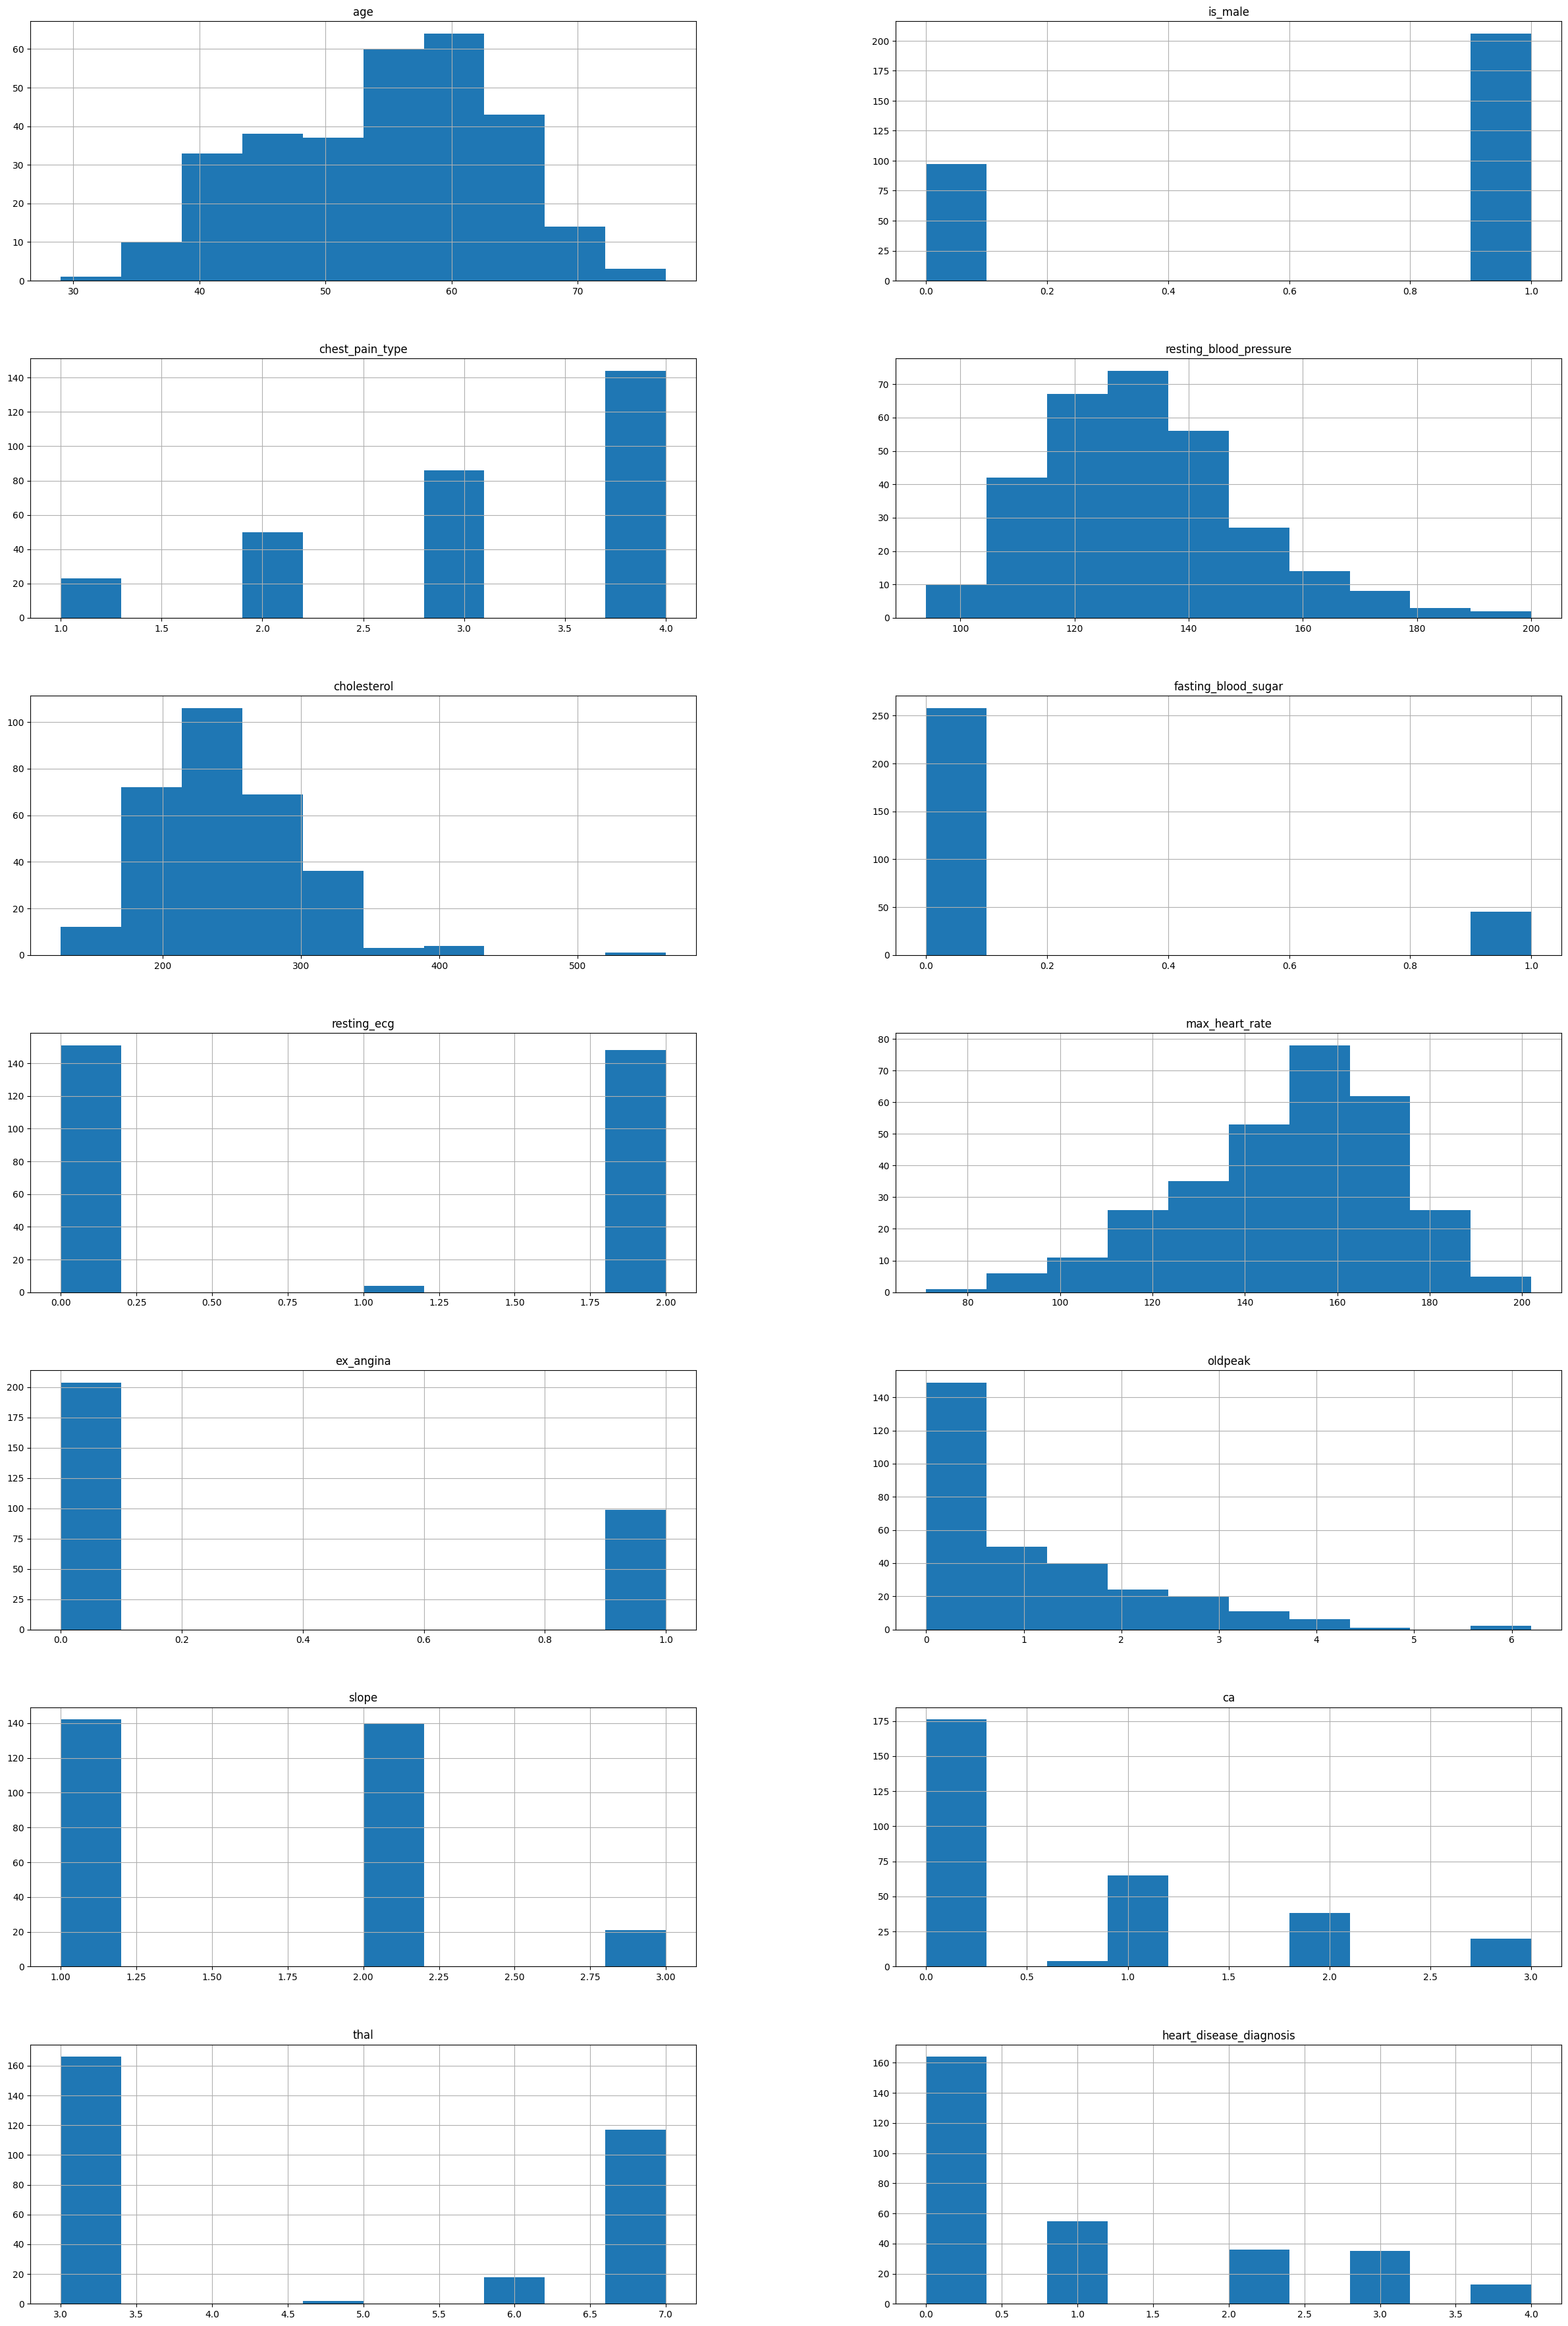

In [113]:
fig, axis = plt.subplots(7, 2)
fig.set_size_inches(30, 45)
processed_cleveland_df.hist(ax=axis)
plt.show()

### Distributions

A few of these (age, resting blood pressure, cholesterol and max heart rate) are skewed distributions. Age and max heart rate skew right (positive), while blood pressure and cholesterol skew left (negative).

oldpeak is a power law distribution.

The rest are discrete distributions with five or fewer options. These don't really need to be normalized, but the other categories do.

Skewed distributions can be normalized using a Box-Cox Transformation followed by Z-score scaling.

Log scaling will be used for oldpeak since it is a power law distribution.

## Encoding

Label encoding will be used for ca, which might not be necessary because it may already be label encoded. I just need to check to be sure.

One hot encoding will be used for chest_pain_type, resting_ecg and thal, which will result in several new columns.

In [114]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [115]:
label_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

processed_cleveland_df["ca Encoded"] = label_encoder.fit_transform(processed_cleveland_df["ca"])

one_hot_encoder_transform = one_hot_encoder.fit_transform(processed_cleveland_df[["chest_pain_type", "resting_ecg", "thal"]])
processed_cleveland_df = pd.concat([processed_cleveland_df, one_hot_encoder_transform], axis=1).drop(columns=["chest_pain_type", "resting_ecg", "thal"])

## Scaling
This made up of two sections:

Use the Box Cox transformation to reduce the skew of age, max heart rate, resting blood pressure, and cholesterol and then use z-score scaling, since the Box Cox Transformation will make the features close enough to a normal distribution.

Using log scaling to scale oldpeak which is a power law distribution.

In [116]:
from scipy.stats import boxcox

In [117]:
column_labels = ["age", "max_heart_rate", "resting_blood_pressure", "cholesterol"]

for column in column_labels:
    boxcox_data, best_lambda = boxcox(processed_cleveland_df[column])
    scaled_series = pd.Series(boxcox_data)
    series_mean = scaled_series.mean()
    series_std = scaled_series.std()
    new_column_label = column + "_scaled"
    processed_cleveland_df[new_column_label] = scaled_series.apply(lambda x: (x - series_mean) / series_std)

Deleting the old unnormalized/scaled columns.

In [118]:
processed_cleveland_df = processed_cleveland_df.drop(columns=["age", "max_heart_rate", "resting_blood_pressure", "cholesterol"])

In [119]:
processed_cleveland_df["oldpeak"] = processed_cleveland_df["oldpeak"].apply(lambda x: 0 if x == 0 else np.log(abs(x)))

In [120]:
processed_cleveland_df.head()

,is_male,fasting_blood_sugar,ex_angina,oldpeak,slope,ca,heart_disease_diagnosis,ca Encoded,chest_pain_type_1.0,chest_pain_type_2.0,...,resting_ecg_1.0,resting_ecg_2.0,thal_3.0,thal_4.696369636963697,thal_6.0,thal_7.0,age_scaled,max_heart_rate_scaled,resting_blood_pressure_scaled,cholesterol_scaled
0,1.0,1.0,0.0,0.832909,3.0,0.0,0,0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.951194,-0.079550,0.824566,-0.169220
1,1.0,0.0,1.0,0.405465,2.0,3.0,2,4,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.433291,-1.672987,1.506109,0.832421
2,1.0,0.0,1.0,0.955511,2.0,2.0,1,3,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.433291,-0.956399,-0.624051,-0.254747
3,1.0,0.0,0.0,1.252763,3.0,0.0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,-1.840453,1.872857,0.011968,0.177154
4,0.0,0.0,0.0,0.336472,1.0,0.0,0,0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,-1.453438,1.017329,0.011968,-0.829343


## Model Selection

In [128]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [129]:
X = processed_cleveland_df.drop("heart_disease_diagnosis", axis = 1)
y = processed_cleveland_df["heart_disease_diagnosis"]

In [130]:
lr = LogisticRegression()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
model_list = [lr, rf, knn]

In [136]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for model in model_list:
    score = cross_val_score(model, X, y, cv=skf, scoring='roc_auc_ovr', error_score='raise')
    print(f"{type(model).__name__} Cross Validation ROC AUC Score:mean: {np.mean(score)}, std: {np.std(score)}")
    score = cross_val_score(model, X, y, cv=skf, scoring='f1_micro')
    print(f"{type(model).__name__} Cross Validation F1 Score:mean: {np.mean(score)}, std: {np.std(score)}")


LogisticRegression Cross Validation ROC AUC Score:mean: 0.7945701398083548, std: 0.024637944913088895
LogisticRegression Cross Validation F1 Score:mean: 0.5774193548387097, std: 0.04711837281538453
RandomForestClassifier Cross Validation ROC AUC Score:mean: 0.7745569995704343, std: 0.050066783052758634
RandomForestClassifier Cross Validation F1 Score:mean: 0.5873118279569892, std: 0.06490884061877
KNeighborsClassifier Cross Validation ROC AUC Score:mean: 0.698929940127736, std: 0.043946758084466624
KNeighborsClassifier Cross Validation F1 Score:mean: 0.5611827956989247, std: 0.05400686826565272


## Results

Regardless of the F1 method used, the models do poorly (60% or less, with a low of 30% for macro) but Logistic Regresssion had a fairly good 

## Optimization

In [137]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
min_max_sc = MinMaxScaler()
make_interactions = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [146]:
c_val_exponents = np.linspace(2, -3, 6)
C_vals = np.array(float(10) ** c_val_exponents)
params={'C':C_vals, 'l1_ratio':[0,0.5,1]}
LogReg=  LogisticRegression(solver='saga', random_state=42, max_iter=10000)
Grid =  GridSearchCV(LogReg, params, return_train_score=True)
scaler_CV_pipeline = Pipeline(steps=[('make_features', make_interactions), ('scaler',min_max_sc),('model', Grid)])
scaler_CV_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('make_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


## Final Models

In [147]:
best_lr = LogisticRegression(C=1.0, l1_ratio=1, max_iter=10000, solver='saga', random_state=42)
best_lr.fit(X_train, y_train)
y_train_predict_proba=best_lr.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba, multi_class='ovr')

0.8807012577645743

## Final Results

I was able to find a pretty good Logistic Regression model (with hyperparameters c=1.0, and l1 ratio = 1) with an ROC AUC score of 88%.